In [40]:
import numpy as mp
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df1 = pd.read_csv(r"C:\Users\Ozoha\Documents\.ipynb_checkpoints\credit-risk-ews\data\data_model_firm.csv")
df2 = pd.read_csv(r"C:\Users\Ozoha\Documents\.ipynb_checkpoints\credit-risk-ews\data\macro_dataset.csv")

,SP_ENTITY_ID,SP_COMPANY_NAME,SP_TICKER,fiscal_year,iq_cash_equiv,iq_cash_oper,iq_ebit,iq_ebitda,iq_interest_exp,iq_lt_debt,...,roa,ocf_to_debt,leverage_w,interest_coverage_w,roa_w,ocf_to_debt_w,distress,distress_lag1,distress_2y,default_t_plus_1
0,103697,GATX Corporation,GATX,2020,292200.0,428300.0,285500.0,627700.0,-191800.0,5329000.0,...,0.031944,0.080017,0.598886,NaN,0.031944,0.080017,0,NaN,0,0.0
1,103697,GATX Corporation,GATX,2021,344300.0,507200.0,292200.0,670600.0,-204700.0,5887500.0,...,0.030623,0.085885,0.618925,NaN,0.030623,0.085885,0,0.0,0,0.0
2,103697,GATX Corporation,GATX,2022,303700.0,533500.0,330100.0,701400.0,-220400.0,6431500.0,...,0.032774,0.082729,0.640270,NaN,0.032774,0.082729,0,0.0,0,0.0
3,103697,GATX Corporation,GATX,2023,450700.0,520400.0,390500.0,782600.0,-278600.0,7388100.0,...,0.034478,0.070333,0.653284,NaN,0.034478,0.070333,0,0.0,0,0.0
4,103697,GATX Corporation,GATX,2024,401600.0,602100.0,477700.0,899100.0,-365300.0,8215300.0,...,0.038848,0.073197,0.668946,NaN,0.038848,0.073197,0,0.0,0,NaN


In [4]:
df_model = pd.merge(df1, df2, left_on = "fiscal_year", right_on = "year", how = "left")
df_model.head()

,SP_ENTITY_ID,SP_COMPANY_NAME,SP_TICKER,fiscal_year,iq_cash_equiv,iq_cash_oper,iq_ebit,iq_ebitda,iq_interest_exp,iq_lt_debt,...,roa_w,ocf_to_debt_w,distress,distress_lag1,distress_2y,default_t_plus_1,year,gdp_growth_lag1,unemployment_lag1,financial_conditions_lag1
0,103697,GATX Corporation,GATX,2020,292200.0,428300.0,285500.0,627700.0,-191800.0,5329000.0,...,0.031944,0.080017,0,NaN,0,0.0,2020,1.192293,3.750,NaN
1,103697,GATX Corporation,GATX,2021,344300.0,507200.0,292200.0,670600.0,-204700.0,5887500.0,...,0.030623,0.085885,0,0.0,0,0.0,2021,0.359914,8.875,NaN
2,103697,GATX Corporation,GATX,2022,303700.0,533500.0,330100.0,701400.0,-220400.0,6431500.0,...,0.032774,0.082729,0,0.0,0,0.0,2022,2.953582,5.600,-0.632345
3,103697,GATX Corporation,GATX,2023,450700.0,520400.0,390500.0,782600.0,-278600.0,7388100.0,...,0.034478,0.070333,0,0.0,0,0.0,2023,1.916286,3.700,-0.267940
4,103697,GATX Corporation,GATX,2024,401600.0,602100.0,477700.0,899100.0,-365300.0,8215300.0,...,0.038848,0.073197,0,0.0,0,NaN,2024,1.510789,3.575,NaN


In [45]:
df_model.columns

Index(['SP_ENTITY_ID', 'SP_COMPANY_NAME', 'SP_TICKER', 'fiscal_year',
       'iq_cash_equiv', 'iq_cash_oper', 'iq_ebit', 'iq_ebitda',
       'iq_interest_exp', 'iq_lt_debt', 'iq_st_debt', 'iq_total_assets',
       'iq_total_rev', 'pcd_total_liab', 'total_debt', 'interest_coverage',
       'leverage', 'roa', 'ocf_to_debt', 'leverage_w', 'interest_coverage_w',
       'roa_w', 'ocf_to_debt_w', 'distress', 'distress_lag1', 'distress_2y',
       'default_t_plus_1', 'year', 'gdp_growth_lag1', 'unemployment_lag1',
       'financial_conditions_lag1'],
      dtype='object')

In [11]:
id_cols = [
    "SP_ENTITY_ID",
    "SP_COMPANY_NAME",
    "SP_TICKER",
    "fiscal_year"]

financial_features = [
    "leverage_w",
    "interest_coverage_w",
    "roa_w",
    "ocf_to_debt_w"]

macro_features = [
    "gdp_growth_lag1",
    "unemployment_lag1",
    "financial_conditions_lag1"]

target_col = [
    "default_t_plus_1"]

In [12]:
model_cols = id_cols + financial_features + macro_features + target_col

In [13]:
df_final = df_model[model_cols].copy()
df_final.head()

,SP_ENTITY_ID,SP_COMPANY_NAME,SP_TICKER,fiscal_year,leverage_w,interest_coverage_w,roa_w,ocf_to_debt_w,gdp_growth_lag1,unemployment_lag1,financial_conditions_lag1,default_t_plus_1
0,103697,GATX Corporation,GATX,2020,0.598886,NaN,0.031944,0.080017,1.192293,3.750,NaN,0.0
1,103697,GATX Corporation,GATX,2021,0.618925,NaN,0.030623,0.085885,0.359914,8.875,NaN,0.0
2,103697,GATX Corporation,GATX,2022,0.640270,NaN,0.032774,0.082729,2.953582,5.600,-0.632345,0.0
3,103697,GATX Corporation,GATX,2023,0.653284,NaN,0.034478,0.070333,1.916286,3.700,-0.267940,0.0
4,103697,GATX Corporation,GATX,2024,0.668946,NaN,0.038848,0.073197,1.510789,3.575,NaN,NaN


In [14]:
df_final.shape

(10459, 12)

In [15]:
df_final.isna().mean().sort_values(ascending = False)

interest_coverage_w          0.999522
leverage_w                   0.776269
ocf_to_debt_w                0.775791
financial_conditions_lag1    0.614112
default_t_plus_1             0.214265
roa_w                        0.017401
SP_COMPANY_NAME              0.000000
SP_ENTITY_ID                 0.000000
fiscal_year                  0.000000
SP_TICKER                    0.000000
unemployment_lag1            0.000000
gdp_growth_lag1              0.000000
dtype: float64

In [16]:
df_final = df_final.dropna(subset = ["default_t_plus_1"]).copy()

In [21]:
feature_cols = [ "leverage_w",
    "interest_coverage_w",
    "roa_w",
    "ocf_to_debt_w",
    "gdp_growth_lag1",
    "unemployment_lag1",
    "financial_conditions_lag1" ]

x = df_final[feature_cols]
y = df_final["default_t_plus_1"]

In [22]:
x_missing_flags = x.isna().astype(int)
x_missing_flags.columns = [f"{c}_missing" for c in x.columns]

x = pd.concat([x,x_missing_flags], axis = 1)
x = x.fillna(x.median())
x.head()

,leverage_w,interest_coverage_w,roa_w,ocf_to_debt_w,gdp_growth_lag1,unemployment_lag1,financial_conditions_lag1,leverage_w_missing,interest_coverage_w_missing,roa_w_missing,ocf_to_debt_w_missing,gdp_growth_lag1_missing,unemployment_lag1_missing,financial_conditions_lag1_missing
0,0.598886,8.529412,0.031944,0.080017,1.192293,3.750,-0.632345,0,1,0,0,0,0,1
1,0.618925,8.529412,0.030623,0.085885,0.359914,8.875,-0.632345,0,1,0,0,0,0,1
2,0.640270,8.529412,0.032774,0.082729,2.953582,5.600,-0.632345,0,1,0,0,0,0,0
3,0.653284,8.529412,0.034478,0.070333,1.916286,3.700,-0.267940,0,1,0,0,0,0,0
5,0.326425,8.529412,0.028600,0.141635,1.192293,3.750,-0.632345,1,1,0,1,0,0,1


In [23]:
x.shape

(8218, 14)

In [26]:
cut_off_year = 2023

train_idx = df_final["fiscal_year"] <= cut_off_year
test_idx = df_final["fiscal_year"] > cut_off_year

x_train = x.loc[train_idx]
x_test = x.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

In [29]:
print(x_train.shape)
print(y_train.shape)

(7782, 14)
(7782,)


#Scaling the Data for LogisticRegression

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(penalty = "l2",
                           solver = "lbfgs",
                          max_iter = 1000)

logit.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [36]:
pd_train = logit.predict_proba(x_train_scaled)[:,1]
pd_test = logit.predict_proba(x_test_scaled)[:,1]

In [38]:
from sklearn.metrics import roc_auc_score

auc_train = roc_auc_score(y_train, pd_train)
auc_test = roc_auc_score(y_test, pd_test)

auc_train, auc_test

(np.float64(0.6619716046500335), np.float64(0.6408864265927977))

In [42]:
from sklearn.metrics import roc_curve
import numpy as np

def ks_statistic(y_true, y_score):
    """
    Computes KS statistic using ROC curve.
    y_true  : actual labels (0/1)
    y_score : predicted probabilities (PDs)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ks = np.max(np.abs(tpr - fpr))
    return ks

ks_train = ks_statistic(y_train, pd_train)
ks_test  = ks_statistic(y_test, pd_test)

ks_train, ks_test

(np.float64(0.25452075962382115), np.float64(0.2760480147737765))

#Altman Z-Score

In [49]:
df_altman = df_final.copy()

df_altman["altman_z"] = (
    1.5 * df_altman["roa_w"].fillna(0) +
    1.0 * df_altman["interest_coverage_w"].fillna(0) -
    1.2 * df_altman["leverage_w"].fillna(0) +
    0.8 * df_altman["ocf_to_debt_w"].fillna(0)
)

altman_risk_score = -df_altman["altman_z"]

In [50]:
from sklearn.metrics import roc_auc_score

auc_altman = roc_auc_score(y, altman_risk_score)
ks_altman = ks_statistic(y, altman_risk_score)

comparison = pd.DataFrame({
    "Model": ["Altman-Style Rules", "Logistic Regression"],
    "AUC": [auc_altman, auc_test],
    "KS": [ks_altman, ks_test]
})

comparison

,Model,AUC,KS
0,Altman-Style Rules,0.551899,0.144875
1,Logistic Regression,0.640886,0.276048


#Machine Learning using RandomForest

In [51]:
from sklearn.ensemble import RandomForestClassifier

# max_depth=6 → prevents overfitting, min_samples_leaf=50 → credit-style smoothing

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = 6,
    min_samples_leaf = 50,
    random_state = 42,
    n_jobs = -1)

rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=50, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [53]:
pd_rf_train = rf.predict_proba(x_train)[:, 1]
pd_rf_test = rf.predict_proba(x_test)[:, 1]

auc_rf_train = roc_auc_score(y_train, pd_rf_train)
auc_rf_test = roc_auc_score(y_test, pd_rf_test)

auc_rf_train, auc_rf_test

(np.float64(0.7619378084154181), np.float64(0.7145706371191136))

In [54]:
ks_rf_train = ks_statistic(y_train, pd_rf_train)
ks_rf_test  = ks_statistic(y_test, pd_rf_test)

ks_rf_train, ks_rf_test

(np.float64(0.3962405334792976), np.float64(0.37961218836565097))

In [57]:
importances = pd.Series(
    rf.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

importances.head(10)

roa_w                                0.397716
leverage_w_missing                   0.211794
ocf_to_debt_w_missing                0.194211
leverage_w                           0.065188
roa_w_missing                        0.059714
ocf_to_debt_w                        0.051677
gdp_growth_lag1                      0.006385
unemployment_lag1                    0.005890
financial_conditions_lag1_missing    0.004161
financial_conditions_lag1            0.003264
dtype: float64

In [55]:
comparison_final = pd.DataFrame({
    "Model": [
        "Altman-Style Rules",
        "Logistic Regression",
        "Random Forest"
    ],
    "AUC": [
        auc_altman,
        auc_test,
        auc_rf_test
    ],
    "KS": [
        ks_altman,
        ks_test,
        ks_rf_test
    ]
})

comparison_final

,Model,AUC,KS
0,Altman-Style Rules,0.551899,0.144875
1,Logistic Regression,0.640886,0.276048
2,Random Forest,0.714571,0.379612


#ROC Curves

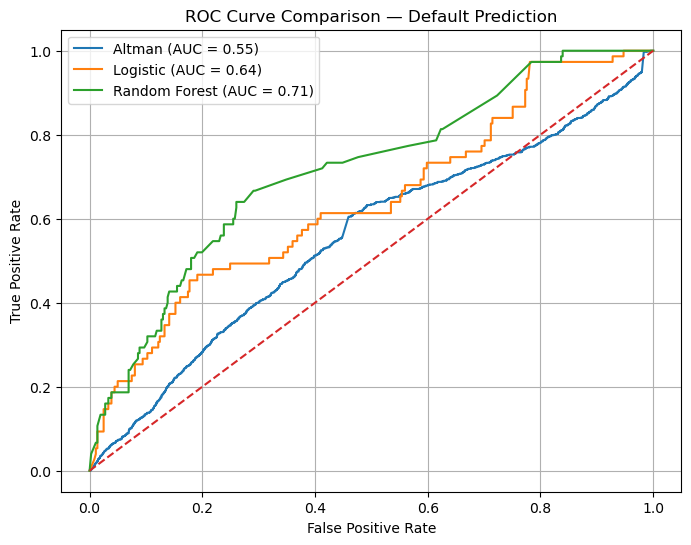

In [75]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

#Altman
fpr_alt, tpr_alt, _ = roc_curve(y, altman_risk_score)

#Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, pd_test)

#Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, pd_rf_test)


plt.figure(figsize=(8, 6))

plt.plot(fpr_alt, tpr_alt, label=f"Altman (AUC = {auc_altman:.2f})")
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_test:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf_test:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Default Prediction")
plt.legend()
plt.grid(True)

plt.savefig(r"C:\Users\Ozoha\Documents\.ipynb_checkpoints\credit-risk-ews\graphs.png", dpi=300, bbox_inches="tight")
plt.show()


#Risk Buckets

In [62]:
df_buckets = (
    x_test
    .copy()
    .assign(
        default=y_test.values,
        pd_rf=pd_rf_test
    ))

df_buckets = (
    df_final
    .loc[x_test.index, ["SP_TICKER", "SP_COMPANY_NAME", "fiscal_year"]]
    .copy())

df_buckets["default"] = y_test.values
df_buckets["pd_rf"] = pd_rf_test

df_buckets["pd_bucket"] = pd.qcut(
    df_buckets["pd_rf"],
    q=10,
    labels=False
)

bucket_summary = (
    df_buckets
    .groupby("pd_bucket")["default"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "default_rate"})
)

bucket_summary


,count,default_rate
pd_bucket,,
0,44,0.000000
1,64,0.125000
2,41,0.146341
3,59,0.084746
4,11,0.090909
5,61,0.081967
6,25,0.240000
7,45,0.266667
8,42,0.333333


In [70]:
companies_by_bucket = (
    df_buckets
    .sort_values("pd_rf", ascending=False)
    .groupby("pd_bucket")[["SP_COMPANY_NAME", "pd_rf", "default"]]
    .apply(lambda x: x.reset_index(drop=True))
)

companies_by_bucket

SP_COMPANY_NAME     pd_rf  default
pd_bucket                                                      
0         0                  Kennametal Inc.  0.021471      0.0
          1           Marwynn Holdings, Inc.  0.021456      0.0
          2        Pyxus International, Inc.  0.021415      0.0
          3                          EnerSys  0.021085      0.0
          4     TransDigm Group Incorporated  0.021023      0.0
...                                      ...       ...      ...
9         39                    Amesite Inc.  0.215257      1.0
          40                   Rest EZ, Inc.  0.215257      1.0
          41  Ocean Power Technologies, Inc.  0.214172      1.0
          42             LSEB Creative Corp.  0.214172      1.0
          43   Texas Mineral Resources Corp.  0.213428      0.0

[436 rows x 3 columns]

In [74]:
for b in sorted(df_buckets["pd_bucket"].unique()):
    (
        df_buckets[df_buckets["pd_bucket"] == b]
        .sort_values("pd_rf", ascending=False)
        [["SP_COMPANY_NAME", "fiscal_year", "pd_rf", "default"]]
        .to_csv(rf"C:\Users\Ozoha\Documents\.ipynb_checkpoints\credit-risk-ews\notebooks\results\risk_bucket_{b}.csv", index=False)
    )